<a href="https://colab.research.google.com/github/AarjavShahh/ML_Repo/blob/main/PDS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("World_happiness_report.csv")
df

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [ ]:
per_capita_region = df.groupby("Country or region")['GDP per capita'].sum()
print(per_capita_region)

Country or region
Afghanistan    0.350
Albania        0.947
Algeria        1.002
Argentina      1.092
Armenia        0.850
               ...  
Venezuela      0.960
Vietnam        0.741
Yemen          0.287
Zambia         0.578
Zimbabwe       0.366
Name: GDP per capita, Length: 156, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


* There are total 156 entries in my dataset.
* 9 features of which 8 are quantitative and 1 is qualitative.
* No null values in dataset.

In [ ]:
print(df.isnull().sum())

df = df.drop(columns=['index', 'Overall rank'], errors='ignore')


Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country or region             156 non-null    object 
 1   Score                         156 non-null    float64
 2   GDP per capita                156 non-null    float64
 3   Social support                156 non-null    float64
 4   Healthy life expectancy       156 non-null    float64
 5   Freedom to make life choices  156 non-null    float64
 6   Generosity                    156 non-null    float64
 7   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.9+ KB


In [ ]:
df

,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...
151,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


* Score Column represents the Happiness Score of each Country

In [ ]:
df['Country or region'].unique()

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

* Each entry has Unique Country.

In [ ]:
df['Score'].describe()

,Score
count,156.000000
mean,5.407096
std,1.113120
min,2.853000
25%,4.544500
50%,5.379500
75%,6.184500
max,7.769000


* Maximum Happiness score is of Finland that is approx 7.77.
* Least Happiness score is of South Sudan that is approx 2.85.

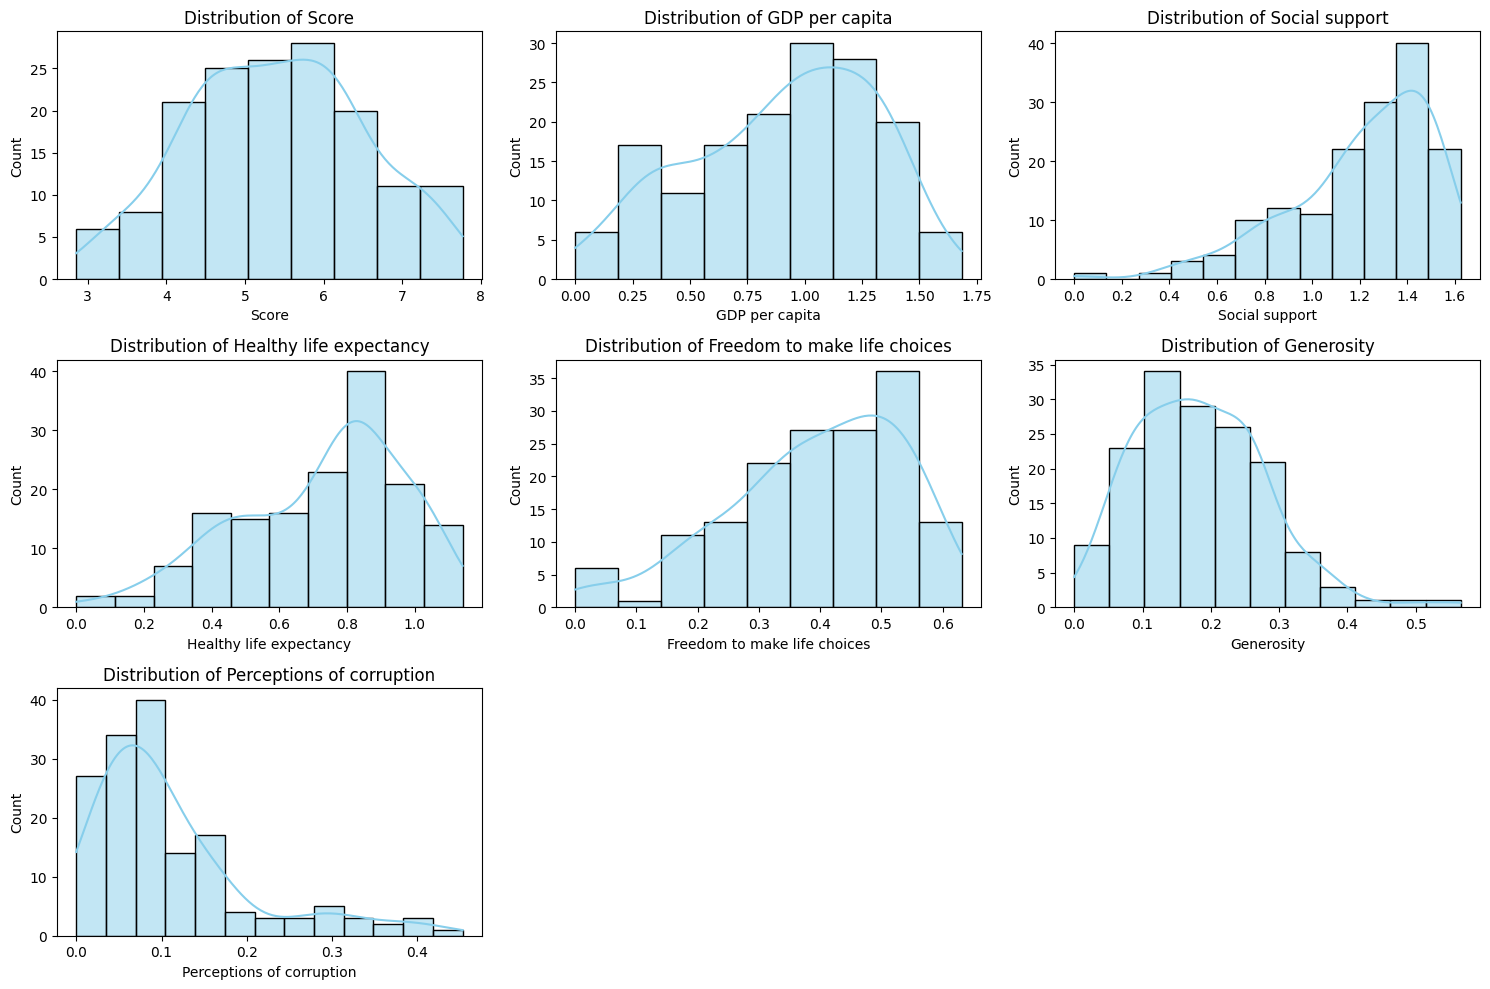

In [ ]:
num_cols = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


* Score: The distribution appears somewhat normal, but with a slight left skew, indicating that there are more countries with lower happiness scores.
* GDP per capita: The distribution is right-skewed, meaning that a larger number of countries have lower GDP per capita.
* Social support: This distribution is also left-skewed, suggesting that most countries have relatively high levels of social support.
* Healthy life expectancy: Similar to social support, this distribution is left-skewed, indicating that most countries have a higher healthy life expectancy.
* Freedom to make life choices: The distribution appears somewhat normal, with a peak around the middle values, suggesting a range of freedom levels across countries.
* Generosity: The distribution is right-skewed, with a large concentration of countries having lower generosity scores.
* Perceptions of corruption: This distribution is heavily right-skewed, indicating that in most countries, the perception of corruption is low. There are a few countries with significantly higher perceptions of corruption.

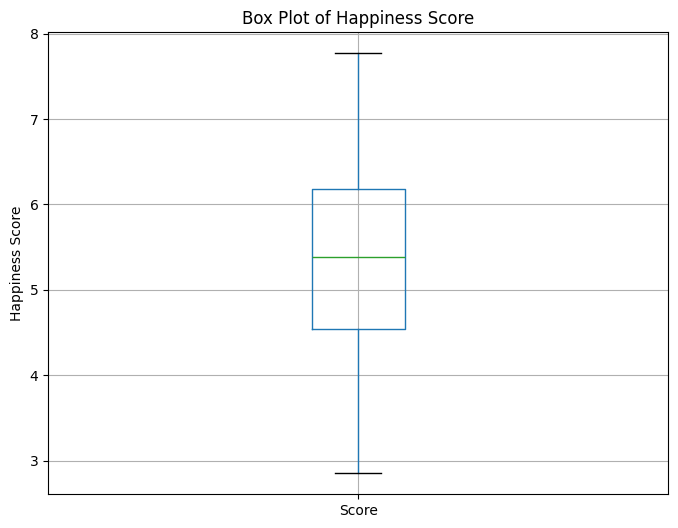

In [ ]:
plt.figure(figsize=(8, 6))
df.boxplot(column="Score")
plt.title("Box Plot of Happiness Score")
plt.ylabel("Happiness Score")
plt.show()

* No outliers in the Dataset.

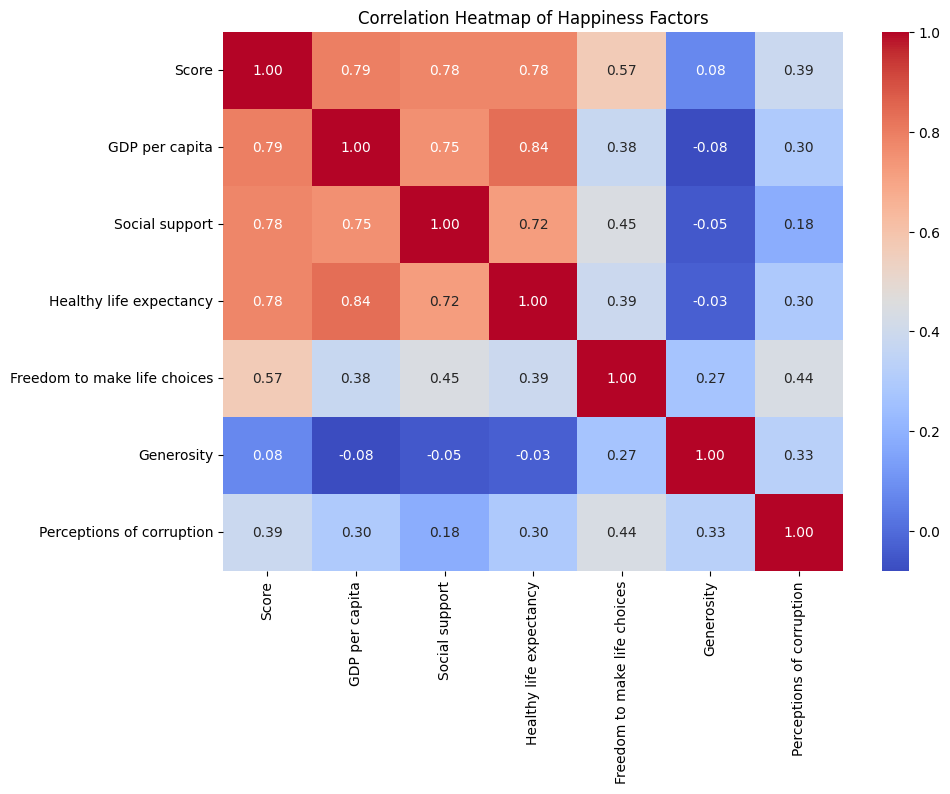

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Happiness Factors')
plt.show()


Heatmap visually represents the correlation between the different numerical features in your dataset.

* The color of the square indicates the strength and direction of the correlation:
  * Colors closer to red indicate a strong positive correlation (as one variable increases, the other tends to increase).
  * Colors closer to blue indicate a strong negative correlation (as one variable increases, the other tends to decrease).
  * Colors closer to white or light shades indicate a weak correlation.
* The number inside each square is the correlation bteween two numbrical values from the dataset, the value of correlation is always between -1 and 1.
  * A value of 1 means a perfect positive correlation.
  * A value of -1 means a perfect negative correlation.
  * A value of 0 means no linear correlation.

* Looking at the heatmap, you can see which factors are most strongly correlated with the 'Score' (Happiness Score) and how the other factors relate to each other. For example, 'GDP per capita', 'Social support', and 'Healthy life expectancy' appear to have strong positive correlations with 'Score'.

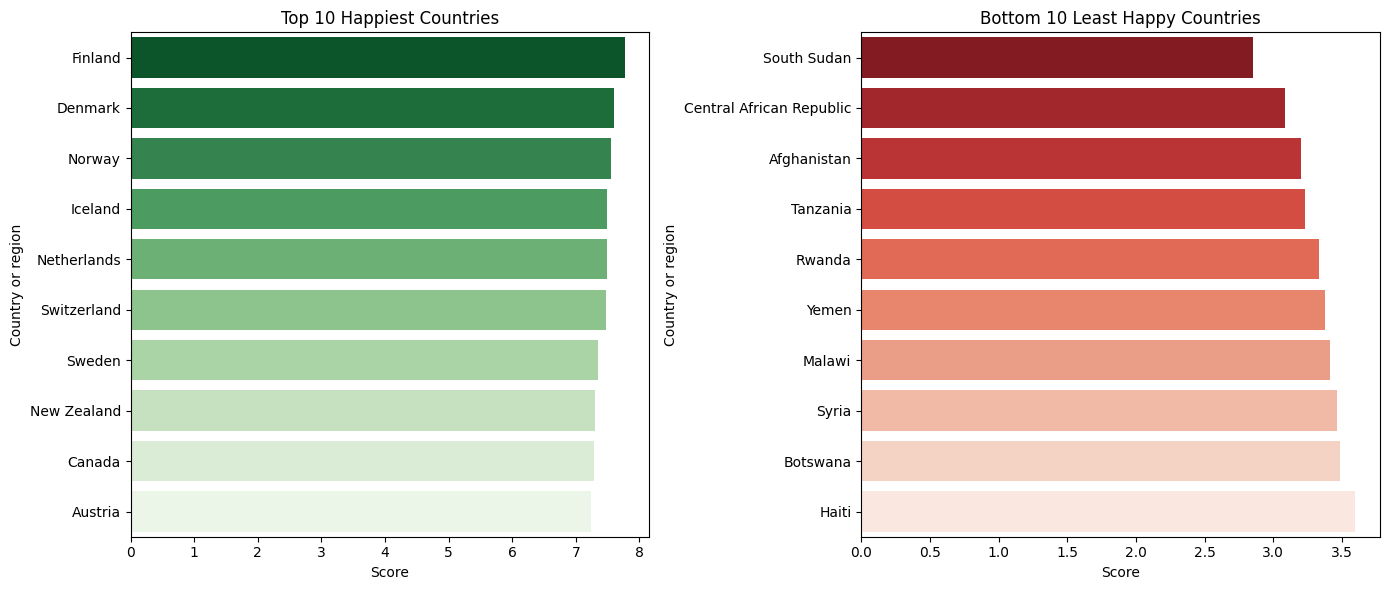

In [ ]:
top_10 = df.nlargest(10, 'Score')
bottom_10 = df.nsmallest(10, 'Score')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(data=top_10, x='Score', y='Country or region', ax=axes[0], palette='Greens_r', hue='Country or region', legend=False)
axes[0].set_title('Top 10 Happiest Countries')
sns.barplot(data=bottom_10, x='Score', y='Country or region', ax=axes[1], palette='Reds_r', hue='Country or region', legend=False)
axes[1].set_title('Bottom 10 Least Happy Countries')
plt.tight_layout()
plt.show()

* Above graph displays the top 10 Happiest countries and Bottom 10 Least Happiest Countries based on their Score.

* Bar length represents the corrosponding Happiness Score of each country.

In [ ]:
corr_with_score = df[num_cols].corr()['Score'].sort_values(ascending=False)
print(corr_with_score)


Score                           1.000000
GDP per capita                  0.793883
Healthy life expectancy         0.779883
Social support                  0.777058
Freedom to make life choices    0.566742
Perceptions of corruption       0.385613
Generosity                      0.075824
Name: Score, dtype: float64


* To identify which feature lead to most Happiness.

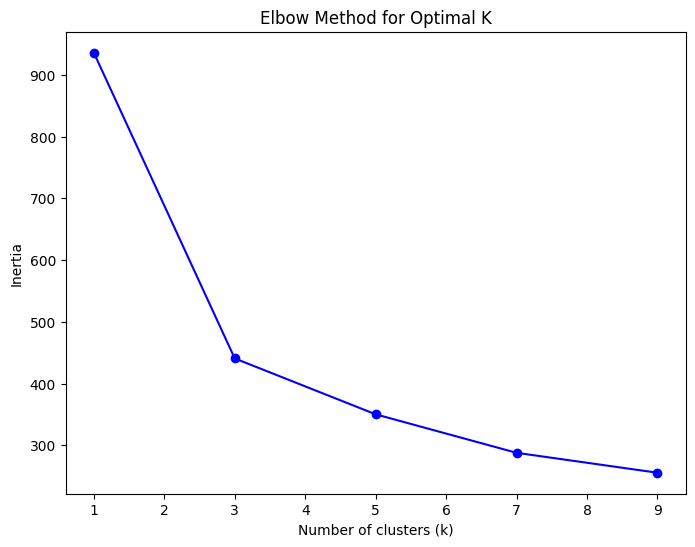

In [ ]:
features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 10, 2)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


* The x-axis represents the number of clusters (k) from 1 to 9.
* The y-axis represents the Inertia, which is the sum of squared distances of samples to their closest cluster center.

* Inertia is used to determine the Quality of clustering.
* Inertia is the sum of squared distances of samples to their closest cluster center.
* Lower Inertia means better clustering.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster')[features].mean().round(2)


,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Cluster,,,,,,
0,1.04,1.31,0.82,0.38,0.13,0.07
1,0.40,0.87,0.42,0.32,0.21,0.10
2,1.32,1.46,0.94,0.54,0.30,0.25


* This output is a table showing the average values of the features for each of the 3 clusters identified by the K-Means algorithm.

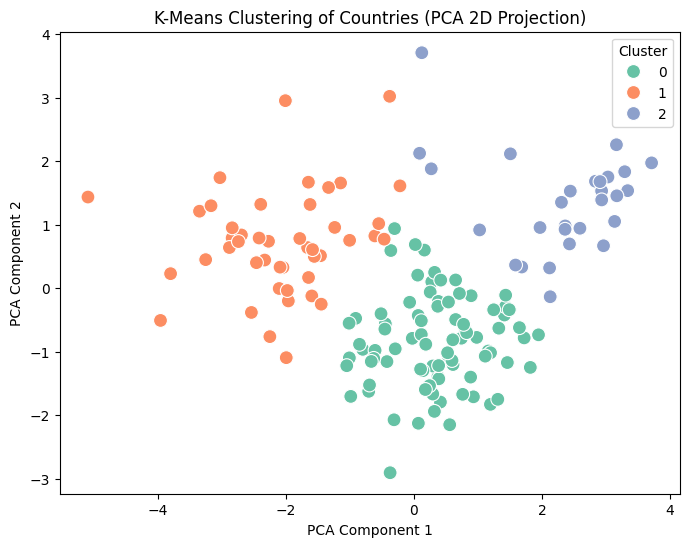

In [ ]:
pca = PCA(2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='Set2', s=100)
plt.title('K-Means Clustering of Countries (PCA 2D Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


* Applied K-means with 3 clusters.
* Through Elbow Method we can determine optimal no. of cluster to use.

Cluster: This column indicates the cluster number (0, 1, and 2).
 These columns show the mean value of each of these features for the countries belonging to that specific cluster.
* Cluster 0 Represents Happiest nations.
* Cluster 1 Represents Moderately Happy Nation.
* Cluster 2 Represents Least Happy Nation.